In [79]:
import requests
import pandas as pd
import datetime
import json
import numpy as np
import matplotlib.pyplot as plt

In [80]:
response = requests.get('http://127.0.0.1:8000/analyses/')
# response.content
analyses = pd.DataFrame(response.json())
analyses_UV = analyses.loc[analyses.Analyse_subname == 'UV']
analyses_RAMAN = analyses.loc[analyses.Analyse_subname == 'RAMAN']

    # format UV
dillution_factor = pd.Series(analyses_UV['Analyse_details'].apply(lambda x : int(x['dillution'].split(":")[1])),name='dillution_factor')
analyses_UV = analyses.loc[analyses.Analyse_subname == 'UV']
data_UV = pd.DataFrame(analyses_UV['Analyses_data'].tolist()).astype(float)
data_UV_dill = data_UV.mul(dillution_factor,axis=0)
indicator_UV = (data_UV_dill['200'] / data_UV_dill['490'])

    # format RAMAN
indicator_RAMAN = analyses_RAMAN['Analyse_details'].apply(lambda x : x['group1_indic1-ex D/G']).astype(float)
data_RAMAN_group1 = pd.DataFrame(analyses_RAMAN['Analyses_data'].tolist()).astype(float)


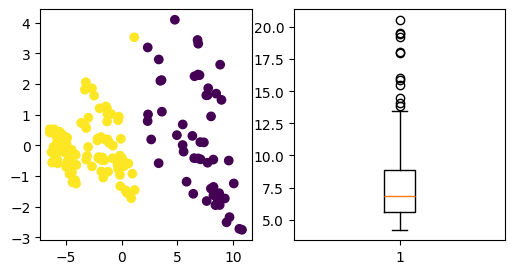

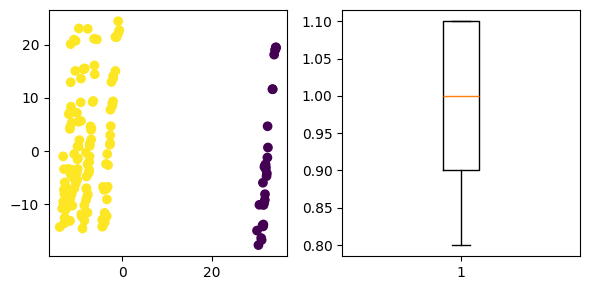

In [81]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans 

sc_UV=StandardScaler()
pca_UV = PCA(n_components=2,random_state=41)
data_UV_dill_sc = sc_UV.fit_transform(data_UV_dill)
weights_UV = pca_UV.fit_transform(data_UV_dill_sc)


f, ax = plt.subplots(1,2,figsize=(6,3))
kmeans_UV = KMeans(n_clusters = 2, random_state=42, n_init='auto').fit(weights_UV)
ax[0].scatter(weights_UV[:,0],weights_UV[:,1], c=kmeans_UV.labels_)
ax[1].boxplot(x=indicator_UV)


sc_RAMAN=StandardScaler()
pca_RAMAN = PCA(n_components=2,random_state=41)
data_RAMAN_group1 = sc_RAMAN.fit_transform(data_RAMAN_group1)
weights_RAMAN = pca_RAMAN.fit_transform(data_RAMAN_group1)

f, ax = plt.subplots(1,2,figsize=(6,3))
kmeans_RAMAN = KMeans(n_clusters = 2, random_state=42, n_init='auto').fit(weights_RAMAN)
ax[0].scatter(weights_RAMAN[:,0],weights_RAMAN[:,1], c=kmeans_RAMAN.labels_)
ax[1].boxplot(x=indicator_RAMAN)



plt.tight_layout()


In [83]:
# export joblib
import joblib
joblib.dump(sc_UV,"Front/Data/sc_UV.joblib")
joblib.dump(indicator_UV,"Front/Data/indicator_UV.joblib")
joblib.dump(pca_UV,"Front/Data/pca_UV.joblib")
joblib.dump(weights_UV,"Front/Data/weights_UV.joblib")
joblib.dump(kmeans_UV,"Front/Data/kmeans_UV.joblib")



joblib.dump(sc_RAMAN,"Front/Data/sc_RAMAN.joblib")
joblib.dump(indicator_RAMAN,"Front/Data/indicator_RAMAN.joblib")
joblib.dump(pca_RAMAN,"Front/Data/pca_RAMAN.joblib")
joblib.dump(weights_RAMAN,"Front/Data/weights_RAMAN.joblib")
joblib.dump(kmeans_RAMAN,"Front/Data/kmeans_RAMAN.joblib")


['Front/Data/kmeans_RAMAN.joblib']

In [84]:
# get values to be updated
sc_UV = joblib.load("Front/Data/sc_UV.joblib")
indicator_UV=joblib.load("Front/Data/indicator_UV.joblib")
pca_UV=joblib.load("Front/Data/pca_UV.joblib")
weights_UV=joblib.load("Front/Data/weights_UV.joblib")
kmeans_UV=joblib.load("Front/Data/kmeans_UV.joblib")

sc_RAMAN=joblib.load("Front/Data/sc_RAMAN.joblib")
indicator_RAMAN=joblib.load("Front/Data/indicator_RAMAN.joblib")
pca_RAMAN=joblib.load("Front/Data/pca_RAMAN.joblib")
weights_RAMAN=joblib.load("Front/Data/weights_RAMAN.joblib")
kmeans_RAMAN=joblib.load("Front/Data/kmeans_RAMAN.joblib")


In [102]:
# make the API CALL
response = requests.get('http://127.0.0.1:8000/OGD/')
OGD_all = pd.DataFrame(response.json())

last_n=5
last_5 = OGD_all['Batch_OGD_name'][-last_n:]

In [103]:
# fetch analysis
UV_data=pd.DataFrame()
RAMAN_data=pd.DataFrame()
for OGD_n in last_5:
    response = requests.get(f'http://127.0.0.1:8000/analyses/name/{OGD_n}')
    analyses = pd.DataFrame(response.json())
    analyse_UV = analyses.loc[analyses.Analyse_subname == 'UV']
    analyse_RAMAN = analyses.loc[analyses.Analyse_subname == 'RAMAN']   
    UV_data = pd.concat([UV_data,analyse_UV])
    RAMAN_data = pd.concat([RAMAN_data,analyse_RAMAN])


In [104]:
# prepare UV with dillution
UV_spectra = pd.DataFrame(UV_data['Analyses_data'].tolist()).astype(float)
dillution_factor = pd.Series(UV_data['Analyse_details'].apply(lambda x : int(x['dillution'].split(":")[1])),name='dillution_factor')
UV_spectra_dill = UV_spectra.mul(dillution_factor.reset_index(drop=True),axis=0)

In [105]:
# geenrate indicators
indic_UV = (UV_spectra_dill['200'] / UV_spectra_dill['490'])[-last_n:]
indic_UV.index=last_5
indic_RAMAN = RAMAN_data['Analyse_details'].apply(lambda x : x['group1_indic1-ex D/G'])[-last_n:]
indic_RAMAN.index=last_5


In [106]:
# prepare sample with scaling and PCA transform
sample_UV = pca_UV.transform(sc_UV.transform(UV_spectra_dill))
sample_RAMAN = pca_RAMAN.transform(sc_RAMAN.transform(pd.DataFrame(RAMAN_data['Analyses_data'].tolist()).astype(float)))

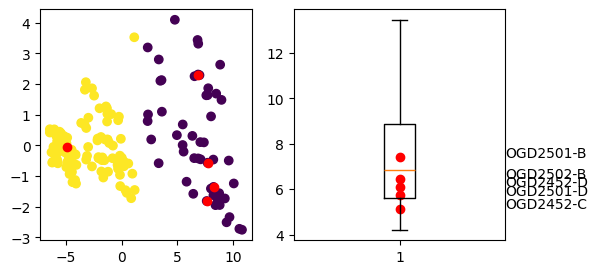

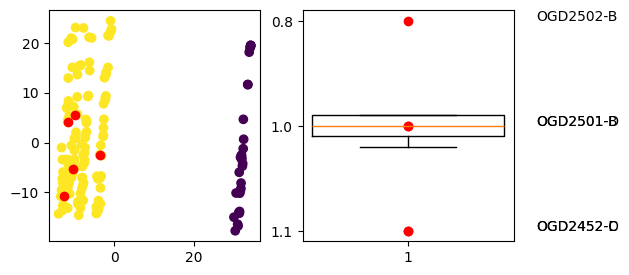

In [107]:

# make figure
f, ax = plt.subplots(1,2,figsize=(6,3))
ax[0].scatter(weights_UV[:,0],weights_UV[:,1], c=kmeans_UV.labels_)
ax[0].scatter(sample_UV[:,0],sample_UV[:,1],c='red')
ax[1].boxplot(x=indicator_UV,showfliers=False)
ax[1].scatter([1 for i in range(last_n)],indic_UV,c='red')
for label in indic_UV.index:
    ax[1].text(1.5,indic_UV[label],s=label)

f, ax = plt.subplots(1,2,figsize=(6,3))
ax[0].scatter(weights_RAMAN[:,0],weights_RAMAN[:,1], c=kmeans_RAMAN.labels_)
ax[0].scatter(sample_RAMAN[:,0],sample_RAMAN[:,1], c='red')
ax[1].boxplot(x=indicator_RAMAN)
ax[1].scatter([1 for i in range(last_n)],indic_RAMAN,c='red')
for label in indic_RAMAN.index:
    ax[1].text(1.1,indic_RAMAN[label],s=label)
    


In [112]:
import plotly.express as px

px.scatter(pd.DataFrame(weights_UV, columns=['PC1','PC2']),x='PC1',y='PC2',color=kmeans_UV.labels_)
px.scatter(pd.DataFrame(sample_UV, columns=['PC1','PC2']),x='PC1',y='PC2',color=['red']*last_n)

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'hovertemplate': 'color=red<br>PC1=%{x}<br>PC2=%{y}<extra></extra>',
              'legendgroup': 'red',
              'marker': {'color': '#636efa', 'symbol': 'circle'},
              'mode': 'markers',
              'name': 'red',
              'orientation': 'v',
              'showlegend': True,
              'type': 'scatter',
              'x': array([ 6.85315159, -4.91627459,  7.7055852 ,  8.2406849 ,  7.62786164]),
              'xaxis': 'x',
              'y': array([ 2.30868042, -0.05152973, -0.56745497, -1.35586218, -1.81581558]),
              'yaxis': 'y'}],
    'layout': {'legend': {'title': {'text': 'color'}, 'tracegroupgap': 0},
               'margin': {'t': 60},
               'template': '...',
               'xaxis': {'anchor': 'y', 'domain': [0.0, 1.0], 'title': {'text': 'PC1'}},
               'yaxis': {'anchor': 'x', 'domain': [0.0, 1.0], 'title': {'text': 'PC2'}}}
})

In [ ]:
pca_UV.transform(sc_UV.transform(pd.DataFrame(UV_data)))

array([[-8.21514408, -0.60771806],
       [-8.18982474, -0.61927612],
       [-8.1725224 , -0.75152483],
       [-8.14576742, -0.79094519],
       [-8.17640858, -0.81394286]])